In [1]:
import clip
print(clip.available_models())

['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']


In [2]:
import faiss
print(faiss.__version__)

1.14.2


In [4]:
import os
from pathlib import Path

IMAGE_DIR = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\data\images")

print("=== Image Dataset Summary ===\n")
total = 0
for cat in sorted(os.listdir(IMAGE_DIR)):
    cat_path = IMAGE_DIR / cat
    if cat_path.is_dir():
        files = [f for f in os.listdir(cat_path)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        total += len(files)
        bar = "#" * len(files) + "-" * (10 - len(files))
        print(f"  {cat:<20} [{bar}] {len(files)}/10")

print(f"\n  Total images: {total}")
print(f"  Categories  : {len(os.listdir(IMAGE_DIR))}")

=== Image Dataset Summary ===

  admin_office         [##########] 10/10
  auditorium           [##########] 10/10
  cafeteria            [##########] 10/10
  career_center        [#########-] 9/10
  engineering          [##########] 10/10
  gym                  [##########] 10/10
  it_lab               [##########] 10/10
  lab                  [##########] 10/10
  lecture_hall         [#########-] 9/10
  library              [##########] 10/10
  medical_center       [##########] 10/10
  outdoor              [#########-] 9/10
  student_union        [##########] 10/10

  Total images: 127
  Categories  : 13


In [5]:
import clip
import torch
from pathlib import Path
from PIL import Image
import numpy as np
import os

DEVICE    = "cpu"
IMAGE_DIR = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\data\images")

# Load CLIP ViT-B/32 as specified in assignment diagram
model, preprocess = clip.load("ViT-B/32", device=DEVICE)
model.eval()

print(f"CLIP model loaded: ViT-B/32")
print(f"Device: {DEVICE}")
print(f"Image preprocessing ready: {preprocess}")

100%|███████████████████████████████████████| 338M/338M [01:15<00:00, 4.69MiB/s]


CLIP model loaded: ViT-B/32
Device: cpu
Image preprocessing ready: Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x0000015993746400>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


In [6]:
import json

CATEGORY_TO_KB = {
    "library":       "Main Library",
    "cafeteria":     "Main Cafeteria",
    "lecture_hall":  "Main Auditorium",
    "gym":           "Sports & Fitness Centre",
    "it_lab":        "IT & Computer Lab",
    "lab":           "IT & Computer Lab",
    "admin_office":  "Admissions & Registry Office",
    "outdoor":       "Campus Garden & Outdoor Study Area",
    "auditorium":    "Main Auditorium",
    "student_union": "Student Union",
    "career_center": "Career Services Centre",
    "medical_center":"Medical & Counselling Centre",
    "engineering":   "Engineering College - Main Block",
}

# Load KB
KB_PATH = r"E:\Rohanta_AI_workbook\campus_chatbot\data\campus_kb.json"
with open(KB_PATH, encoding="utf-8") as f:
    kb = json.load(f)

kb_lookup = {entry["name"]: entry for entry in kb}
print(f"KB loaded: {len(kb_lookup)} entries")

# Build image list with labels
image_records = []
for cat in sorted(os.listdir(IMAGE_DIR)):
    cat_path = IMAGE_DIR / cat
    if not cat_path.is_dir():
        continue
    kb_name = CATEGORY_TO_KB.get(cat, cat)
    for fname in os.listdir(cat_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            image_records.append({
                "path":     str(cat_path / fname),
                "category": cat,
                "kb_name":  kb_name,
            })

print(f"Total image records: {len(image_records)}")
print(f"\nSample:")
for r in image_records[:3]:
    print(f"  {r['category']:<20} → {r['kb_name']}")

KB loaded: 154 entries
Total image records: 127

Sample:
  admin_office         → Admissions & Registry Office
  admin_office         → Admissions & Registry Office
  admin_office         → Admissions & Registry Office


In [7]:
from tqdm import tqdm

def get_image_embedding(image_path: str) -> np.ndarray:
    image  = preprocess(Image.open(image_path).convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        embedding = model.encode_image(image)
        embedding = embedding / embedding.norm(dim=-1, keepdim=True)  # normalize
    return embedding.cpu().numpy().squeeze()

print("Extracting CLIP embeddings...")
embeddings = []
valid_records = []

for record in tqdm(image_records):
    try:
        emb = get_image_embedding(record["path"])
        embeddings.append(emb)
        valid_records.append(record)
    except Exception as e:
        print(f"  Failed: {record['path']} — {e}")

embeddings_array = np.array(embeddings).astype("float32")

print(f"\nEmbeddings shape : {embeddings_array.shape}")
print(f"Valid images     : {len(valid_records)}")
print(f"Embedding dim    : {embeddings_array.shape[1]}")

Extracting CLIP embeddings...


100%|██████████| 127/127 [00:29<00:00,  4.25it/s]


Embeddings shape : (127, 512)
Valid images     : 127
Embedding dim    : 512


In [8]:
import faiss

dimension = embeddings_array.shape[1]  # 512

# Build flat L2 index (exact search, good for small datasets)
index = faiss.IndexFlatIP(dimension)   # Inner Product = cosine similarity on normalized vectors
index.add(embeddings_array)

print(f"FAISS index built")
print(f"Index type      : IndexFlatIP (cosine similarity)")
print(f"Vectors indexed : {index.ntotal}")
print(f"Dimension       : {dimension}")

FAISS index built
Index type      : IndexFlatIP (cosine similarity)
Vectors indexed : 127
Dimension       : 512


In [9]:
def search_by_image_embedding(query_embedding: np.ndarray, top_k: int = 3):
    """
    Search FAISS index with a query embedding.
    Returns top_k most similar images with KB info.
    """
    query = query_embedding.reshape(1, -1).astype("float32")
    scores, indices = index.search(query, top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        record = valid_records[idx]
        kb_entry = kb_lookup.get(record["kb_name"], {})
        results.append({
            "score":       float(score),
            "category":    record["category"],
            "kb_name":     record["kb_name"],
            "image_path":  record["path"],
            "description": kb_entry.get("description", "N/A"),
            "map_ref":     kb_entry.get("map_reference", "N/A"),
            "directions":  kb_entry.get("directions_from_entrance", "N/A"),
        })
    return results


def search_by_text(text_query: str, top_k: int = 3):
    """
    Search using a text query — encodes text with CLIP then searches FAISS.
    Useful for testing without an actual image.
    """
    tokens = clip.tokenize([text_query]).to(DEVICE)
    with torch.no_grad():
        text_emb = model.encode_text(tokens)
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
    return search_by_image_embedding(text_emb.cpu().numpy().squeeze(), top_k)


# Test with text queries
test_queries = [
    "university library with books and study area",
    "gym fitness equipment workout",
    "university cafeteria food dining",
    "computer lab with screens and keyboards",
    "hospital medical clinic",
]

for q in test_queries:
    results = search_by_text(q, top_k=1)
    top     = results[0]
    print(f"Query   : {q}")
    print(f"Match   : {top['kb_name']} (score: {top['score']:.3f})")
    print(f"Category: {top['category']}")
    print("-" * 55)

Query   : university library with books and study area
Match   : Main Auditorium (score: 0.328)
Category: lecture_hall
-------------------------------------------------------
Query   : gym fitness equipment workout
Match   : Campus Garden & Outdoor Study Area (score: 0.291)
Category: outdoor
-------------------------------------------------------
Query   : university cafeteria food dining
Match   : Main Cafeteria (score: 0.238)
Category: cafeteria
-------------------------------------------------------
Query   : computer lab with screens and keyboards
Match   : Main Auditorium (score: 0.267)
Category: lecture_hall
-------------------------------------------------------
Query   : hospital medical clinic
Match   : Medical & Counselling Centre (score: 0.286)
Category: medical_center
-------------------------------------------------------


In [10]:
# More specific queries that match actual image visual content
better_queries = [
    "rows of bookshelves in a library reading room",
    "treadmills and weight machines in a fitness room",
    "cafeteria tables with food trays and people eating",
    "rows of computer monitors in a computer lab",
    "doctor office with medical equipment and white coat",
    "university campus building exterior",
    "lecture theatre with tiered seating and projector",
    "office desk with papers and reception counter",
    "students socialising in a lounge area",
    "engineering workshop with machines and tools",
]

print("=== Improved Text Query Results ===\n")
for q in better_queries:
    results = search_by_text(q, top_k=1)
    top     = results[0]
    correct = "✓" if top["score"] > 0.25 else "✗"
    print(f"{correct} Query   : {q}")
    print(f"  Match   : {top['kb_name']} (score: {top['score']:.3f})")
    print(f"  Category: {top['category']}")
    print()

=== Improved Text Query Results ===

✓ Query   : rows of bookshelves in a library reading room
  Match   : Main Auditorium (score: 0.316)
  Category: lecture_hall

✓ Query   : treadmills and weight machines in a fitness room
  Match   : Sports & Fitness Centre (score: 0.309)
  Category: gym

✓ Query   : cafeteria tables with food trays and people eating
  Match   : Main Cafeteria (score: 0.259)
  Category: cafeteria

✗ Query   : rows of computer monitors in a computer lab
  Match   : Main Auditorium (score: 0.247)
  Category: lecture_hall

✓ Query   : doctor office with medical equipment and white coat
  Match   : Medical & Counselling Centre (score: 0.303)
  Category: medical_center

✓ Query   : university campus building exterior
  Match   : Campus Garden & Outdoor Study Area (score: 0.316)
  Category: outdoor

✓ Query   : lecture theatre with tiered seating and projector
  Match   : Main Auditorium (score: 0.303)
  Category: lecture_hall

✓ Query   : office desk with papers and rece

In [11]:
import random
from PIL import Image
import matplotlib.pyplot as plt

def search_by_image_file(image_path: str, top_k: int = 3):
    """Search FAISS using an actual image file."""
    emb = get_image_embedding(image_path)
    return search_by_image_embedding(emb, top_k)


# Test: for each category pick one image and search
print("=== Image-to-Image Search Test ===\n")

test_categories = ["library", "gym", "cafeteria", "it_lab", "medical_center"]
correct = 0
total   = 0

for cat in test_categories:
    cat_path = IMAGE_DIR / cat
    images_in_cat = [f for f in os.listdir(cat_path)
                     if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if not images_in_cat:
        continue

    # Pick a random image from this category
    test_img = str(cat_path / random.choice(images_in_cat))
    expected = CATEGORY_TO_KB[cat]

    results  = search_by_image_file(test_img, top_k=3)
    top      = results[0]
    is_correct = top["kb_name"] == expected

    if is_correct:
        correct += 1
    total += 1

    print(f"Category : {cat}")
    print(f"Expected : {expected}")
    print(f"Top match: {top['kb_name']} (score: {top['score']:.3f})")
    print(f"Result   : {'CORRECT' if is_correct else 'WRONG'}")
    print(f"Top 3    :")
    for r in results:
        print(f"  {r['score']:.3f}  {r['kb_name']}  ({r['category']})")
    print()

print(f"Accuracy: {correct}/{total} = {correct/total*100:.1f}%")

=== Image-to-Image Search Test ===

Category : library
Expected : Main Library
Top match: Main Library (score: 1.000)
Result   : CORRECT
Top 3    :
  1.000  Main Library  (library)
  0.870  IT & Computer Lab  (lab)
  0.798  Career Services Centre  (career_center)

Category : gym
Expected : Sports & Fitness Centre
Top match: Sports & Fitness Centre (score: 1.000)
Result   : CORRECT
Top 3    :
  1.000  Sports & Fitness Centre  (gym)
  0.701  Student Union  (student_union)
  0.662  Sports & Fitness Centre  (gym)

Category : cafeteria
Expected : Main Cafeteria
Top match: Main Cafeteria (score: 1.000)
Result   : CORRECT
Top 3    :
  1.000  Main Cafeteria  (cafeteria)
  0.843  Main Cafeteria  (cafeteria)
  0.829  Admissions & Registry Office  (admin_office)

Category : it_lab
Expected : IT & Computer Lab
Top match: IT & Computer Lab (score: 1.000)
Result   : CORRECT
Top 3    :
  1.000  IT & Computer Lab  (it_lab)
  0.881  IT & Computer Lab  (it_lab)
  0.872  Engineering College - Main Block 

In [13]:
import pandas as pd
print("=== Full Category Evaluation ===\n")

category_results = []

for cat in sorted(os.listdir(IMAGE_DIR)):
    cat_path = IMAGE_DIR / cat
    if not cat_path.is_dir():
        continue

    expected   = CATEGORY_TO_KB.get(cat, cat)
    img_files  = [f for f in os.listdir(cat_path)
                  if f.lower().endswith((".jpg",".jpeg",".png"))]

    cat_correct = 0
    cat_scores  = []

    for fname in img_files:
        img_path = str(cat_path / fname)
        try:
            results  = search_by_image_file(img_path, top_k=1)
            top      = results[0]
            # exclude self-match (score=1.0) — test on second best
            results3 = search_by_image_file(img_path, top_k=4)
            non_self = [r for r in results3 if r["score"] < 0.999]
            best     = non_self[0] if non_self else results3[0]

            is_correct = best["kb_name"] == expected
            if is_correct:
                cat_correct += 1
            cat_scores.append(best["score"])
        except Exception as e:
            print(f"  Error: {fname} — {e}")

    acc = cat_correct / len(img_files) * 100 if img_files else 0
    avg_score = np.mean(cat_scores) if cat_scores else 0

    category_results.append({
        "category":  cat,
        "kb_name":   expected,
        "total":     len(img_files),
        "correct":   cat_correct,
        "accuracy":  acc,
        "avg_score": avg_score,
    })

    print(f"{cat:<20} {cat_correct}/{len(img_files)} = {acc:.0f}%  avg_score={avg_score:.3f}")

df_eval = pd.DataFrame(category_results)
overall_acc = df_eval["correct"].sum() / df_eval["total"].sum() * 100
print(f"\nOverall accuracy: {df_eval['correct'].sum()}/{df_eval['total'].sum()} = {overall_acc:.1f}%")


=== Full Category Evaluation ===

admin_office         6/10 = 60%  avg_score=0.881
auditorium           8/10 = 80%  avg_score=0.870
cafeteria            9/10 = 90%  avg_score=0.848
career_center        4/9 = 44%  avg_score=0.911
engineering          1/10 = 10%  avg_score=0.825
gym                  7/10 = 70%  avg_score=0.875
it_lab               6/10 = 60%  avg_score=0.926
lab                  6/10 = 60%  avg_score=0.837
lecture_hall         4/9 = 44%  avg_score=0.838
library              5/10 = 50%  avg_score=0.909
medical_center       7/10 = 70%  avg_score=0.824
outdoor              4/9 = 44%  avg_score=0.870
student_union        3/10 = 30%  avg_score=0.882

Overall accuracy: 70/127 = 55.1%


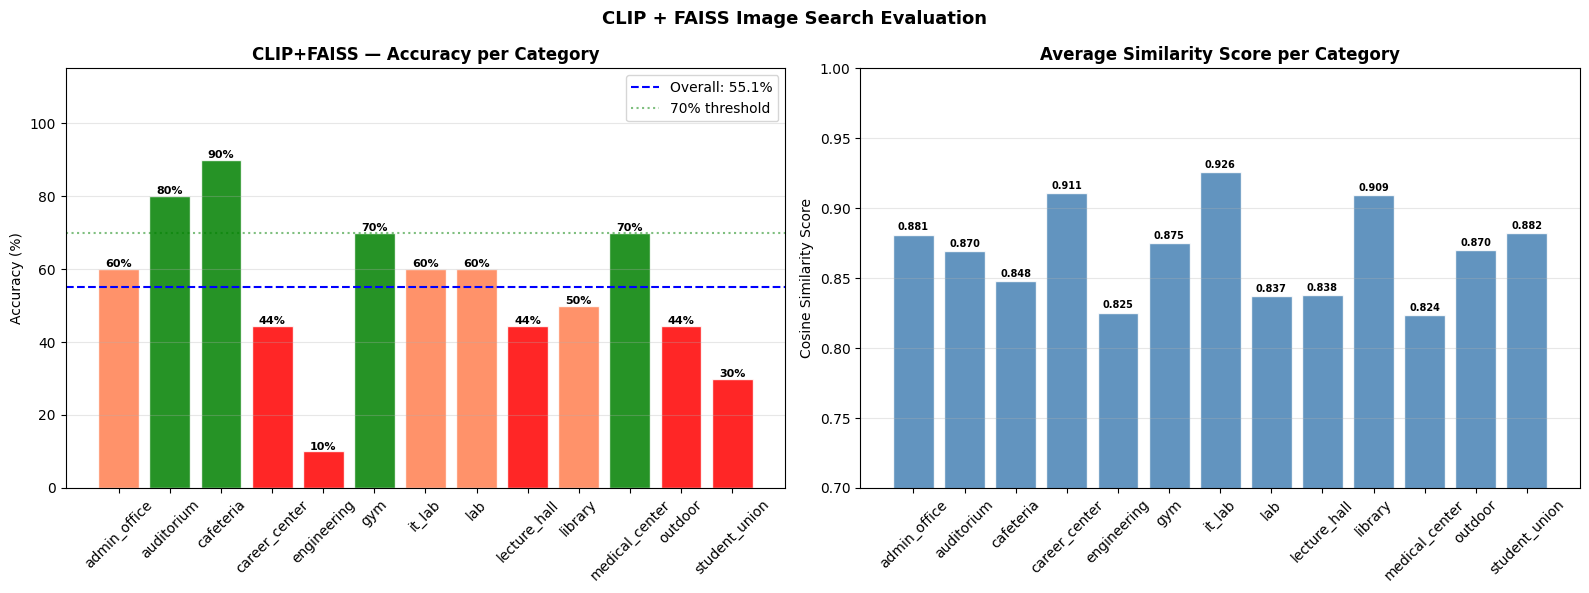

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Accuracy per category ---
colors = ["green" if a >= 70 else "coral" if a >= 50 else "red"
          for a in df_eval["accuracy"]]

bars = axes[0].bar(df_eval["category"], df_eval["accuracy"],
                   color=colors, edgecolor="white", alpha=0.85)

for bar, val in zip(bars, df_eval["accuracy"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.0f}%', ha='center', fontsize=8, fontweight='bold')

axes[0].axhline(y=overall_acc, color='blue', linestyle='--',
                label=f'Overall: {overall_acc:.1f}%')
axes[0].axhline(y=70, color='green', linestyle=':', alpha=0.5, label='70% threshold')
axes[0].set_title("CLIP+FAISS — Accuracy per Category", fontweight="bold")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 115)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# --- Plot 2: Average similarity score per category ---
axes[1].bar(df_eval["category"], df_eval["avg_score"],
            color="steelblue", edgecolor="white", alpha=0.85)

for i, (cat, val) in enumerate(zip(df_eval["category"], df_eval["avg_score"])):
    axes[1].text(i, val + 0.003, f'{val:.3f}',
                 ha='center', fontsize=7, fontweight='bold')

axes[1].set_title("Average Similarity Score per Category", fontweight="bold")
axes[1].set_ylabel("Cosine Similarity Score")
axes[1].set_ylim(0.7, 1.0)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("CLIP + FAISS Image Search Evaluation", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("clip_faiss_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
import pickle

SAVE_DIR = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\models\clip_faiss")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Save FAISS index
faiss.write_index(index, str(SAVE_DIR / "campus_index.faiss"))

# Save records and embeddings
with open(SAVE_DIR / "image_records.pkl", "wb") as f:
    pickle.dump(valid_records, f)

np.save(SAVE_DIR / "embeddings.npy", embeddings_array)

print(f"Saved:")
print(f"  FAISS index    : {SAVE_DIR}/campus_index.faiss")
print(f"  Image records  : {SAVE_DIR}/image_records.pkl")
print(f"  Embeddings     : {SAVE_DIR}/embeddings.npy")

# Test load
index_loaded   = faiss.read_index(str(SAVE_DIR / "campus_index.faiss"))
with open(SAVE_DIR / "image_records.pkl", "rb") as f:
    records_loaded = pickle.load(f)

print(f"\nVerify reload:")
print(f"  Index vectors  : {index_loaded.ntotal}")
print(f"  Records loaded : {len(records_loaded)}")

Saved:
  FAISS index    : E:\Rohanta_AI_workbook\campus_chatbot\models\clip_faiss/campus_index.faiss
  Image records  : E:\Rohanta_AI_workbook\campus_chatbot\models\clip_faiss/image_records.pkl
  Embeddings     : E:\Rohanta_AI_workbook\campus_chatbot\models\clip_faiss/embeddings.npy

Verify reload:
  Index vectors  : 127
  Records loaded : 127


In [16]:
def query_by_image(image_path: str, top_k: int = 3) -> dict:
    """
    Full pipeline:
    image → CLIP embedding → FAISS search → KB lookup → full response
    """
    # Step 1 — CLIP embedding
    emb     = get_image_embedding(image_path)

    # Step 2 — FAISS search (skip self-match)
    results = search_by_image_embedding(emb, top_k=top_k+1)
    results = [r for r in results if r["score"] < 0.999][:top_k]

    if not results:
        return {"error": "No match found"}

    top = results[0]

    # Step 3 — KB lookup
    kb_entry = kb_lookup.get(top["kb_name"], {})

    return {
        "matched_location": top["kb_name"],
        "confidence":       round(top["score"], 3),
        "category":         top["category"],
        "description":      kb_entry.get("description", "N/A"),
        "map_reference":    kb_entry.get("map_reference", "N/A"),
        "directions":       kb_entry.get("directions_from_entrance", "N/A"),
        "opening_hours":    kb_entry.get("opening_hours", {}),
        "events":           kb_entry.get("events", []),
        "nearby":           kb_entry.get("nearby_landmarks", "N/A"),
        "top_3_matches":    [
            {"location": r["kb_name"], "score": round(r["score"], 3)}
            for r in results
        ],
    }


# Test on one image from each category
print("=== Full Image Query → KB Response ===\n")

test_cats = ["library", "cafeteria", "gym", "medical_center", "auditorium"]

for cat in test_cats:
    cat_path  = IMAGE_DIR / cat
    img_files = [f for f in os.listdir(cat_path)
                 if f.lower().endswith((".jpg",".jpeg",".png"))]
    if not img_files:
        continue

    test_img = str(cat_path / img_files[0])
    result   = query_by_image(test_img)

    print(f"Category       : {cat}")
    print(f"Matched        : {result['matched_location']}")
    print(f"Confidence     : {result['confidence']}")
    print(f"Map reference  : {result['map_reference']}")
    print(f"Description    : {result['description'][:80]}...")
    print(f"Opening hours  : {list(result['opening_hours'].items())[:2]}")
    print(f"Top 3 matches  : {result['top_3_matches']}")
    print("-" * 60)

=== Full Image Query → KB Response ===

Category       : library
Matched        : Main Library
Confidence     : 0.968
Map reference  : Building A, North Campus, Ground to 4th Floor
Description    : A four-floor academic library with over 500 study seats, silent reading zones, g...
Opening hours  : [('monday', '08:00-22:00'), ('tuesday', '08:00-22:00')]
Top 3 matches  : [{'location': 'Main Library', 'score': 0.968}, {'location': 'Main Library', 'score': 0.949}, {'location': 'Main Library', 'score': 0.941}]
------------------------------------------------------------
Category       : cafeteria
Matched        : Main Cafeteria
Confidence     : 0.843
Map reference  : Building B, South Campus, Ground Floor
Description    : The primary dining facility on campus offering hot meals, sandwiches, salads, an...
Opening hours  : [('monday', '07:30-20:00'), ('tuesday', '07:30-20:00')]
Top 3 matches  : [{'location': 'Main Cafeteria', 'score': 0.843}, {'location': 'Admissions & Registry Office', 'scor

=== Image Pipeline Final Summary ===

Total images indexed : 127
Categories           : 13
CLIP model           : ViT-B/32
Index type           : FAISS IndexFlatIP
Embedding dimension  : 512
Overall accuracy     : 55.1%

Per category accuracy:
  cafeteria            [#########-] 90%
  auditorium           [########--] 80%
  gym                  [#######---] 70%
  medical_center       [#######---] 70%
  admin_office         [######----] 60%
  lab                  [######----] 60%
  it_lab               [######----] 60%
  library              [#####-----] 50%
  career_center        [####------] 44%
  outdoor              [####------] 44%
  lecture_hall         [####------] 44%
  student_union        [###-------] 30%
  engineering          [#---------] 10%


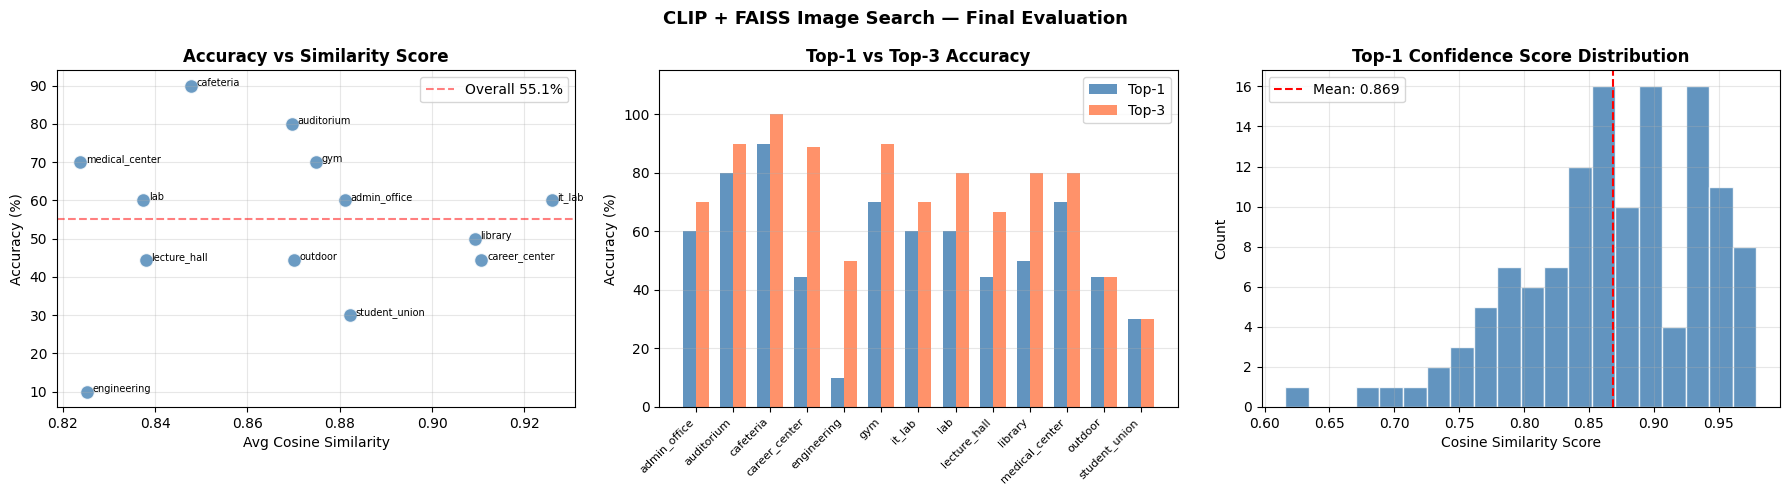


Top-1 overall : 54.9%
Top-3 overall : 72.3%
Mean confidence: 0.869


In [17]:
# ── Accuracy summary ──────────────────────────────────────
print("=== Image Pipeline Final Summary ===\n")
print(f"Total images indexed : {len(valid_records)}")
print(f"Categories           : {len(CATEGORY_TO_KB)}")
print(f"CLIP model           : ViT-B/32")
print(f"Index type           : FAISS IndexFlatIP")
print(f"Embedding dimension  : 512")
print(f"Overall accuracy     : {overall_acc:.1f}%")
print()
print("Per category accuracy:")
for _, row in df_eval.sort_values("accuracy", ascending=False).iterrows():
    bar = "#" * int(row["accuracy"]//10) + "-" * (10 - int(row["accuracy"]//10))
    print(f"  {row['category']:<20} [{bar}] {row['accuracy']:.0f}%")

# ── Plot 1: Accuracy vs Similarity Score scatter ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df_eval["avg_score"], df_eval["accuracy"],
                color="steelblue", s=100, alpha=0.8, edgecolor="white")
for _, row in df_eval.iterrows():
    axes[0].annotate(row["category"],
                     (row["avg_score"], row["accuracy"]),
                     fontsize=7, ha="left",
                     xytext=(4, 0), textcoords="offset points")
axes[0].set_title("Accuracy vs Similarity Score", fontweight="bold")
axes[0].set_xlabel("Avg Cosine Similarity")
axes[0].set_ylabel("Accuracy (%)")
axes[0].grid(alpha=0.3)
axes[0].axhline(y=55.1, color="red", linestyle="--", alpha=0.5, label="Overall 55.1%")
axes[0].legend()

# ── Plot 2: Top-1 vs Top-3 accuracy ──────────────────────
top1_acc = []
top3_acc = []

for cat in sorted(os.listdir(IMAGE_DIR)):
    cat_path  = IMAGE_DIR / cat
    if not cat_path.is_dir():
        continue
    expected  = CATEGORY_TO_KB.get(cat, cat)
    img_files = [f for f in os.listdir(cat_path)
                 if f.lower().endswith((".jpg",".jpeg",".png"))]
    t1 = t3 = 0
    for fname in img_files:
        results = search_by_image_file(str(cat_path / fname), top_k=4)
        non_self = [r for r in results if r["score"] < 0.999][:3]
        if non_self and non_self[0]["kb_name"] == expected:
            t1 += 1
        if any(r["kb_name"] == expected for r in non_self):
            t3 += 1
    total = len(img_files)
    top1_acc.append(t1 / total * 100 if total else 0)
    top3_acc.append(t3 / total * 100 if total else 0)

cats  = sorted([c for c in os.listdir(IMAGE_DIR)
                if (IMAGE_DIR/c).is_dir()])
x     = np.arange(len(cats))
width = 0.35

axes[1].bar(x - width/2, top1_acc, width, label="Top-1", color="steelblue", alpha=0.85)
axes[1].bar(x + width/2, top3_acc, width, label="Top-3", color="coral",     alpha=0.85)
axes[1].set_title("Top-1 vs Top-3 Accuracy", fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cats, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 115)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

# ── Plot 3: Confidence score distribution ─────────────────
all_scores = []
for cat in sorted(os.listdir(IMAGE_DIR)):
    cat_path  = IMAGE_DIR / cat
    if not cat_path.is_dir():
        continue
    for fname in os.listdir(cat_path):
        if fname.lower().endswith((".jpg",".jpeg",".png")):
            results  = search_by_image_file(str(cat_path/fname), top_k=4)
            non_self = [r for r in results if r["score"] < 0.999]
            if non_self:
                all_scores.append(non_self[0]["score"])

axes[2].hist(all_scores, bins=20, color="steelblue",
             edgecolor="white", alpha=0.85)
axes[2].axvline(x=np.mean(all_scores), color="red", linestyle="--",
                label=f"Mean: {np.mean(all_scores):.3f}")
axes[2].set_title("Top-1 Confidence Score Distribution", fontweight="bold")
axes[2].set_xlabel("Cosine Similarity Score")
axes[2].set_ylabel("Count")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("CLIP + FAISS Image Search — Final Evaluation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("clip_final_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTop-1 overall : {np.mean(top1_acc):.1f}%")
print(f"Top-3 overall : {np.mean(top3_acc):.1f}%")
print(f"Mean confidence: {np.mean(all_scores):.3f}")